In [2]:
# ============================================================
# 05_econometric_models
# Master Thesis: Profitability and Financial Structure Models
# ============================================================

print("05_econometric_models notebook started.")

05_econometric_models notebook started.


**Cell 2 - Import libraries and mount Drive**

In [3]:
import os
import numpy as np
import pandas as pd

import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

from google.colab import drive
drive.mount("/content/drive")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries loaded.")

Mounted at /content/drive
Libraries loaded.


**Cell 3 - Set paths**

In [4]:
BASE_PATH = "/content/drive/MyDrive/IBS_7_Thesis/Python Files"

DATA_PATH = os.path.join(
    BASE_PATH,
    "analysis_outputs",
    "04_descriptive_summary",
    "04_14_model_ready_dataset.csv"
)

OUT_DIR = os.path.join(BASE_PATH, "analysis_outputs", "05_econometric_models")
os.makedirs(OUT_DIR, exist_ok=True)

print("Data path:")
print(DATA_PATH)

print("\nOutput folder:")
print(OUT_DIR)

Data path:
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/04_descriptive_summary/04_14_model_ready_dataset.csv

Output folder:
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models


**Cell 4 - Load model-ready dataset**

In [5]:
df = pd.read_csv(DATA_PATH, low_memory=False)

print("Model-ready dataset loaded.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Model-ready dataset loaded.
Rows: 91617
Columns: 18


,profit_margin_win,roa_win,roe_win,equity_ratio_calc_win,debt_ratio_win,cash_to_assets_win,receivables_to_assets_win,asset_turnover_win,debt_to_equity_ratio_win,cash_ratio_win,receivables_turnover_win,log_assets,log_revenue,financial_year,status_group,wz_section,wz_4digit,is_financial_sector
0,-0.1645,-0.1670,-0.5673,0.2943,0.5268,0.2219,0.0877,1.0150,1.7900,0.4212,11.5724,13.4295,13.4444,"2,024.0000",active,"M Professional, scientific and technical activ...",71.1200,False
1,-0.0505,-0.3198,-0.3509,0.9114,0.0433,0.4907,0.4875,6.3273,0.0475,11.3360,12.9798,13.4293,15.2741,"2,022.0000",active,"M Professional, scientific and technical activ...",71.1100,False
2,0.1212,0.1962,0.8504,0.2307,0.2390,0.6259,0.2676,1.6187,1.0361,2.6184,6.0480,13.4292,13.9108,"2,023.0000",active,"M Professional, scientific and technical activ...",71.1200,False
3,0.1964,0.3179,0.4311,0.7373,0.2016,0.9114,0.0735,1.6188,0.2734,4.5215,22.0199,13.4292,13.9108,"2,023.0000",active,"M Professional, scientific and technical activ...",71.1200,False
4,0.0020,0.0096,0.0122,0.7862,0.1655,0.2394,0.2823,4.7099,0.2105,1.4462,16.6849,13.4290,14.9787,"2,023.0000",active,"M Professional, scientific and technical activ...",71.2000,False


**Cell 5 - Check available columns**

In [6]:
df.columns.tolist()

['profit_margin_win',
 'roa_win',
 'roe_win',
 'equity_ratio_calc_win',
 'debt_ratio_win',
 'cash_to_assets_win',
 'receivables_to_assets_win',
 'asset_turnover_win',
 'debt_to_equity_ratio_win',
 'cash_ratio_win',
 'receivables_turnover_win',
 'log_assets',
 'log_revenue',
 'financial_year',
 'status_group',
 'wz_section',
 'wz_4digit',
 'is_financial_sector']

**Cell 6 - Detect key columns**

In [7]:
def pick_col(possible_names):
    for col in possible_names:
        if col in df.columns:
            return col
    return None


YEAR_COL = pick_col(["financial_year", "year", "Year"])
SECTOR_COL = pick_col(["wz_section", "WZ_section", "section", "wz_section_label"])
FIN_SECTOR_COL = pick_col(["is_financial_sector", "financial_sector"])

print("YEAR_COL:", YEAR_COL)
print("SECTOR_COL:", SECTOR_COL)
print("FIN_SECTOR_COL:", FIN_SECTOR_COL)

YEAR_COL: financial_year
SECTOR_COL: wz_section
FIN_SECTOR_COL: is_financial_sector


**Cell 7 - Prepare model data**

In [8]:
needed_cols = [
    "roa_win",
    "profit_margin_win",
    "debt_ratio_win",
    "equity_ratio_calc_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

for col in [YEAR_COL, SECTOR_COL, FIN_SECTOR_COL]:
    if col is not None:
        needed_cols.append(col)

needed_cols = list(dict.fromkeys(needed_cols))

model_df = df[needed_cols].copy()

# Convert year and sector to categorical controls
if YEAR_COL is not None:
    model_df[YEAR_COL] = model_df[YEAR_COL].astype("category")

if SECTOR_COL is not None:
    model_df[SECTOR_COL] = model_df[SECTOR_COL].astype("category")

print("Model data prepared.")
print("Rows before dropping missing values:", model_df.shape[0])

display(model_df.head())

Model data prepared.
Rows before dropping missing values: 91617


,roa_win,profit_margin_win,debt_ratio_win,equity_ratio_calc_win,cash_to_assets_win,receivables_to_assets_win,asset_turnover_win,log_assets,financial_year,wz_section,is_financial_sector
0,-0.1670,-0.1645,0.5268,0.2943,0.2219,0.0877,1.0150,13.4295,"2,024.0000","M Professional, scientific and technical activ...",False
1,-0.3198,-0.0505,0.0433,0.9114,0.4907,0.4875,6.3273,13.4293,"2,022.0000","M Professional, scientific and technical activ...",False
2,0.1962,0.1212,0.2390,0.2307,0.6259,0.2676,1.6187,13.4292,"2,023.0000","M Professional, scientific and technical activ...",False
3,0.3179,0.1964,0.2016,0.7373,0.9114,0.0735,1.6188,13.4292,"2,023.0000","M Professional, scientific and technical activ...",False
4,0.0096,0.0020,0.1655,0.7862,0.2394,0.2823,4.7099,13.4290,"2,023.0000","M Professional, scientific and technical activ...",False


**Cell 8 - Model sample availibility**

In [9]:
main_model_vars = [
    "roa_win",
    "profit_margin_win",
    "debt_ratio_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

if YEAR_COL is not None:
    main_model_vars.append(YEAR_COL)

if SECTOR_COL is not None:
    main_model_vars.append(SECTOR_COL)

sample_check = []

for outcome in ["roa_win", "profit_margin_win"]:
    vars_used = main_model_vars.copy()
    vars_used[0] = outcome

    temp = model_df[vars_used].dropna()

    sample_check.append({
        "outcome": outcome,
        "complete_case_n": temp.shape[0],
        "share_of_full_sample_pct": temp.shape[0] / len(df) * 100
    })

sample_check = pd.DataFrame(sample_check)

sample_check_path = os.path.join(OUT_DIR, "05_01_model_sample_availability.csv")
sample_check.to_csv(sample_check_path, index=False)

display(sample_check)
print("Saved:", sample_check_path)

,outcome,complete_case_n,share_of_full_sample_pct
0,roa_win,71169,77.6810
1,profit_margin_win,71275,77.7967


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_01_model_sample_availability.csv


**Cell 9 - Define regression formulas**

In [10]:
# Main model formula components
controls = " + log_assets"

if SECTOR_COL is not None:
    controls += f" + C({SECTOR_COL})"

if YEAR_COL is not None:
    controls += f" + C({YEAR_COL})"


formula_m1 = (
    "roa_win ~ debt_ratio_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win"
    + controls
)

formula_m2 = (
    "profit_margin_win ~ debt_ratio_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win"
    + controls
)

formula_m3 = (
    "roa_win ~ equity_ratio_calc_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win"
    + controls
)

print("M1:", formula_m1)
print("\nM2:", formula_m2)
print("\nM3:", formula_m3)

M1: roa_win ~ debt_ratio_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + log_assets + C(wz_section) + C(financial_year)

M2: profit_margin_win ~ debt_ratio_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + log_assets + C(wz_section) + C(financial_year)

M3: roa_win ~ equity_ratio_calc_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + log_assets + C(wz_section) + C(financial_year)


**Cell 10 - Run main models with robust standard errors**

In [11]:
m1_roa = smf.ols(formula_m1, data=model_df).fit(cov_type="HC3")
m2_profit_margin = smf.ols(formula_m2, data=model_df).fit(cov_type="HC3")
m3_roa_equity = smf.ols(formula_m3, data=model_df).fit(cov_type="HC3")

print("Models estimated with HC3 robust standard errors.")

Models estimated with HC3 robust standard errors.


**Cell 11 - Show compact model summaries**

In [12]:
print("M1 — ROA model")
print(m1_roa.summary())

print("\n\nM2 — Profit margin model")
print(m2_profit_margin.summary())

print("\n\nM3 — ROA alternative equity-ratio model")
print(m3_roa_equity.summary())

M1 — ROA model
                            OLS Regression Results                            
Dep. Variable:                roa_win   R-squared:                       0.115
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     260.2
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:46:56   Log-Likelihood:                 31050.
No. Observations:               71715   AIC:                        -6.204e+04
Df Residuals:                   71687   BIC:                        -6.179e+04
Df Model:                          27                                         
Covariance Type:                  HC3                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------

**Cell 12 - Extract important coeddicies only**

In [13]:
def extract_key_results(model, model_name, key_vars):
    rows = []

    for var in key_vars:
        if var in model.params.index:
            rows.append({
                "model": model_name,
                "variable": var,
                "coef": model.params[var],
                "std_error": model.bse[var],
                "t_value": model.tvalues[var],
                "p_value": model.pvalues[var],
                "conf_low": model.conf_int().loc[var, 0],
                "conf_high": model.conf_int().loc[var, 1],
                "nobs": int(model.nobs),
                "r_squared": model.rsquared,
                "adj_r_squared": model.rsquared_adj
            })

    return pd.DataFrame(rows)


key_vars_m1_m2 = [
    "debt_ratio_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

key_vars_m3 = [
    "equity_ratio_calc_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

results_main = pd.concat([
    extract_key_results(m1_roa, "M1_ROA_debt_ratio", key_vars_m1_m2),
    extract_key_results(m2_profit_margin, "M2_profit_margin_debt_ratio", key_vars_m1_m2),
    extract_key_results(m3_roa_equity, "M3_ROA_equity_ratio", key_vars_m3)
], ignore_index=True)

results_main_path = os.path.join(OUT_DIR, "05_02_main_model_key_results.csv")
results_main.to_csv(results_main_path, index=False)

display(results_main)

print("Saved:", results_main_path)

,model,variable,coef,std_error,t_value,p_value,conf_low,conf_high,nobs,r_squared,adj_r_squared
0,M1_ROA_debt_ratio,debt_ratio_win,-0.0926,0.0020,-46.5409,0.0000,-0.0965,-0.0887,71715,0.1152,0.1148
1,M1_ROA_debt_ratio,cash_to_assets_win,0.1283,0.0036,35.6864,0.0000,0.1212,0.1353,71715,0.1152,0.1148
2,M1_ROA_debt_ratio,receivables_to_assets_win,0.0375,0.0029,12.7951,0.0000,0.0318,0.0433,71715,0.1152,0.1148
3,M1_ROA_debt_ratio,asset_turnover_win,-0.0017,0.0002,-8.1047,0.0000,-0.0022,-0.0013,71715,0.1152,0.1148
4,M1_ROA_debt_ratio,log_assets,0.0021,0.0005,4.4340,0.0000,0.0012,0.0030,71715,0.1152,0.1148
5,M2_profit_margin_debt_ratio,debt_ratio_win,-0.0620,0.0018,-35.0031,0.0000,-0.0655,-0.0585,71275,0.2351,0.2348
6,M2_profit_margin_debt_ratio,cash_to_assets_win,0.0552,0.0031,17.6282,0.0000,0.0491,0.0614,71275,0.2351,0.2348
7,M2_profit_margin_debt_ratio,receivables_to_assets_win,-0.0088,0.0025,-3.4953,0.0005,-0.0138,-0.0039,71275,0.2351,0.2348
8,M2_profit_margin_debt_ratio,asset_turnover_win,-0.0058,0.0001,-40.0562,0.0000,-0.0061,-0.0055,71275,0.2351,0.2348
9,M2_profit_margin_debt_ratio,log_assets,0.0005,0.0004,1.3755,0.1690,-0.0002,0.0013,71275,0.2351,0.2348


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_02_main_model_key_results.csv


**Cell 13 - Multicollinearity check using VIF**

In [14]:
vif_vars = [
    "debt_ratio_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

vif_df = model_df[vif_vars].dropna().copy()

vif_results = pd.DataFrame({
    "variable": vif_vars,
    "VIF": [
        variance_inflation_factor(vif_df.values, i)
        for i in range(len(vif_vars))
    ]
})

vif_path = os.path.join(OUT_DIR, "05_03_vif_main_model.csv")
vif_results.to_csv(vif_path, index=False)

display(vif_results)

print("Saved:", vif_path)

,variable,VIF
0,debt_ratio_win,2.8566
1,cash_to_assets_win,1.9965
2,receivables_to_assets_win,2.7148
3,asset_turnover_win,2.3015
4,log_assets,5.6464


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_03_vif_main_model.csv


**Cell 14 - Financial-sector robustness sample**

In [15]:
if FIN_SECTOR_COL is not None:
    non_fin_df = model_df[model_df[FIN_SECTOR_COL] == False].copy()

    print("Non-financial sample created.")
    print("Rows:", non_fin_df.shape[0])
else:
    non_fin_df = None
    print("Financial-sector column not found. Robustness model cannot be run.")

Non-financial sample created.
Rows: 76644


**Cell 15 - Run robusteness models excluding fiancial-sector firms**

In [16]:
if non_fin_df is not None:
    m4_roa_nonfin = smf.ols(formula_m1, data=non_fin_df).fit(cov_type="HC3")
    m5_pm_nonfin = smf.ols(formula_m2, data=non_fin_df).fit(cov_type="HC3")

    print("Robustness models estimated.")

    print("\nM4 — ROA excluding financial sector")
    print(m4_roa_nonfin.summary())

    print("\n\nM5 — Profit margin excluding financial sector")
    print(m5_pm_nonfin.summary())
else:
    print("Skipped because financial-sector column is unavailable.")

Robustness models estimated.

M4 — ROA excluding financial sector
                            OLS Regression Results                            
Dep. Variable:                roa_win   R-squared:                       0.120
Model:                            OLS   Adj. R-squared:                  0.119
Method:                 Least Squares   F-statistic:                     253.2
Date:                Fri, 05 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:46:58   Log-Likelihood:                 29104.
No. Observations:               62222   AIC:                        -5.815e+04
Df Residuals:                   62195   BIC:                        -5.791e+04
Df Model:                          26                                         
Covariance Type:                  HC3                                         
                                                                           coef    std err          z      P>|z|      [0.025      0.975]
-------

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 26
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 27, but rank is 26
  warnings.warn('covariance of constraints does not have full '


**Cell 16 - Extract robustness results**

In [17]:
if non_fin_df is not None:
    results_robustness = pd.concat([
        extract_key_results(m4_roa_nonfin, "M4_ROA_non_financial", key_vars_m1_m2),
        extract_key_results(m5_pm_nonfin, "M5_profit_margin_non_financial", key_vars_m1_m2)
    ], ignore_index=True)

    robustness_path = os.path.join(OUT_DIR, "05_04_robustness_non_financial_results.csv")
    results_robustness.to_csv(robustness_path, index=False)

    display(results_robustness)
    print("Saved:", robustness_path)
else:
    print("Skipped because financial-sector column is unavailable.")

,model,variable,coef,std_error,t_value,p_value,conf_low,conf_high,nobs,r_squared,adj_r_squared
0,M4_ROA_non_financial,debt_ratio_win,-0.0935,0.0022,-43.1758,0.0000,-0.0977,-0.0892,62222,0.1198,0.1194
1,M4_ROA_non_financial,cash_to_assets_win,0.1283,0.0038,34.0975,0.0000,0.1210,0.1357,62222,0.1198,0.1194
2,M4_ROA_non_financial,receivables_to_assets_win,0.0501,0.0032,15.5625,0.0000,0.0438,0.0564,62222,0.1198,0.1194
3,M4_ROA_non_financial,asset_turnover_win,-0.0021,0.0002,-9.3822,0.0000,-0.0025,-0.0017,62222,0.1198,0.1194
4,M4_ROA_non_financial,log_assets,0.0044,0.0005,8.3005,0.0000,0.0034,0.0055,62222,0.1198,0.1194
5,M5_profit_margin_non_financial,debt_ratio_win,-0.0607,0.0019,-31.9180,0.0000,-0.0645,-0.0570,61862,0.2673,0.2670
6,M5_profit_margin_non_financial,cash_to_assets_win,0.0492,0.0032,15.3382,0.0000,0.0429,0.0554,61862,0.2673,0.2670
7,M5_profit_margin_non_financial,receivables_to_assets_win,0.0069,0.0029,2.4238,0.0154,0.0013,0.0125,61862,0.2673,0.2670
8,M5_profit_margin_non_financial,asset_turnover_win,-0.0060,0.0002,-38.2829,0.0000,-0.0063,-0.0056,61862,0.2673,0.2670
9,M5_profit_margin_non_financial,log_assets,0.0004,0.0004,0.8611,0.3892,-0.0005,0.0013,61862,0.2673,0.2670


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_04_robustness_non_financial_results.csv


**Cell 17 - Combined regression results table**

In [18]:
if non_fin_df is not None:
    combined_results = pd.concat([results_main, results_robustness], ignore_index=True)
else:
    combined_results = results_main.copy()

combined_path = os.path.join(OUT_DIR, "05_05_combined_regression_key_results.csv")
combined_results.to_csv(combined_path, index=False)

display(combined_results)

print("Saved:", combined_path)

,model,variable,coef,std_error,t_value,p_value,conf_low,conf_high,nobs,r_squared,adj_r_squared
0,M1_ROA_debt_ratio,debt_ratio_win,-0.0926,0.0020,-46.5409,0.0000,-0.0965,-0.0887,71715,0.1152,0.1148
1,M1_ROA_debt_ratio,cash_to_assets_win,0.1283,0.0036,35.6864,0.0000,0.1212,0.1353,71715,0.1152,0.1148
2,M1_ROA_debt_ratio,receivables_to_assets_win,0.0375,0.0029,12.7951,0.0000,0.0318,0.0433,71715,0.1152,0.1148
3,M1_ROA_debt_ratio,asset_turnover_win,-0.0017,0.0002,-8.1047,0.0000,-0.0022,-0.0013,71715,0.1152,0.1148
4,M1_ROA_debt_ratio,log_assets,0.0021,0.0005,4.4340,0.0000,0.0012,0.0030,71715,0.1152,0.1148
5,M2_profit_margin_debt_ratio,debt_ratio_win,-0.0620,0.0018,-35.0031,0.0000,-0.0655,-0.0585,71275,0.2351,0.2348
6,M2_profit_margin_debt_ratio,cash_to_assets_win,0.0552,0.0031,17.6282,0.0000,0.0491,0.0614,71275,0.2351,0.2348
7,M2_profit_margin_debt_ratio,receivables_to_assets_win,-0.0088,0.0025,-3.4953,0.0005,-0.0138,-0.0039,71275,0.2351,0.2348
8,M2_profit_margin_debt_ratio,asset_turnover_win,-0.0058,0.0001,-40.0562,0.0000,-0.0061,-0.0055,71275,0.2351,0.2348
9,M2_profit_margin_debt_ratio,log_assets,0.0005,0.0004,1.3755,0.1690,-0.0002,0.0013,71275,0.2351,0.2348


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_05_combined_regression_key_results.csv


**Cell 18 - Create thesis interpretation helper**

In [19]:
def significance_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""


interpretation_table = combined_results.copy()
interpretation_table["significance"] = interpretation_table["p_value"].apply(significance_stars)

interpretation_table["direction"] = np.where(
    interpretation_table["coef"] > 0,
    "Positive",
    "Negative"
)

interpretation_table["short_interpretation"] = (
    interpretation_table["variable"]
    + " has a "
    + interpretation_table["direction"].str.lower()
    + " association with the dependent variable in "
    + interpretation_table["model"]
    + "."
)

interpretation_path = os.path.join(OUT_DIR, "05_06_interpretation_helper.csv")
interpretation_table.to_csv(interpretation_path, index=False)

display(interpretation_table)

print("Saved:", interpretation_path)

,model,variable,coef,std_error,t_value,p_value,conf_low,conf_high,nobs,r_squared,adj_r_squared,significance,direction,short_interpretation
0,M1_ROA_debt_ratio,debt_ratio_win,-0.0926,0.0020,-46.5409,0.0000,-0.0965,-0.0887,71715,0.1152,0.1148,***,Negative,debt_ratio_win has a negative association with...
1,M1_ROA_debt_ratio,cash_to_assets_win,0.1283,0.0036,35.6864,0.0000,0.1212,0.1353,71715,0.1152,0.1148,***,Positive,cash_to_assets_win has a positive association ...
2,M1_ROA_debt_ratio,receivables_to_assets_win,0.0375,0.0029,12.7951,0.0000,0.0318,0.0433,71715,0.1152,0.1148,***,Positive,receivables_to_assets_win has a positive assoc...
3,M1_ROA_debt_ratio,asset_turnover_win,-0.0017,0.0002,-8.1047,0.0000,-0.0022,-0.0013,71715,0.1152,0.1148,***,Negative,asset_turnover_win has a negative association ...
4,M1_ROA_debt_ratio,log_assets,0.0021,0.0005,4.4340,0.0000,0.0012,0.0030,71715,0.1152,0.1148,***,Positive,log_assets has a positive association with the...
5,M2_profit_margin_debt_ratio,debt_ratio_win,-0.0620,0.0018,-35.0031,0.0000,-0.0655,-0.0585,71275,0.2351,0.2348,***,Negative,debt_ratio_win has a negative association with...
6,M2_profit_margin_debt_ratio,cash_to_assets_win,0.0552,0.0031,17.6282,0.0000,0.0491,0.0614,71275,0.2351,0.2348,***,Positive,cash_to_assets_win has a positive association ...
7,M2_profit_margin_debt_ratio,receivables_to_assets_win,-0.0088,0.0025,-3.4953,0.0005,-0.0138,-0.0039,71275,0.2351,0.2348,***,Negative,receivables_to_assets_win has a negative assoc...
8,M2_profit_margin_debt_ratio,asset_turnover_win,-0.0058,0.0001,-40.0562,0.0000,-0.0061,-0.0055,71275,0.2351,0.2348,***,Negative,asset_turnover_win has a negative association ...
9,M2_profit_margin_debt_ratio,log_assets,0.0005,0.0004,1.3755,0.1690,-0.0002,0.0013,71275,0.2351,0.2348,,Positive,log_assets has a positive association with the...


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_06_interpretation_helper.csv


**Cell 19 - Save model formulas**

In [20]:
model_formulas = pd.DataFrame([
    {
        "model": "M1",
        "dependent_variable": "roa_win",
        "formula": formula_m1,
        "sample": "All firms"
    },
    {
        "model": "M2",
        "dependent_variable": "profit_margin_win",
        "formula": formula_m2,
        "sample": "All firms"
    },
    {
        "model": "M3",
        "dependent_variable": "roa_win",
        "formula": formula_m3,
        "sample": "All firms"
    },
    {
        "model": "M4",
        "dependent_variable": "roa_win",
        "formula": formula_m1,
        "sample": "Non-financial firms only"
    },
    {
        "model": "M5",
        "dependent_variable": "profit_margin_win",
        "formula": formula_m2,
        "sample": "Non-financial firms only"
    }
])

formula_path = os.path.join(OUT_DIR, "05_07_model_formulas.csv")
model_formulas.to_csv(formula_path, index=False)

display(model_formulas)

print("Saved:", formula_path)

,model,dependent_variable,formula,sample
0,M1,roa_win,roa_win ~ debt_ratio_win + cash_to_assets_win ...,All firms
1,M2,profit_margin_win,profit_margin_win ~ debt_ratio_win + cash_to_a...,All firms
2,M3,roa_win,roa_win ~ equity_ratio_calc_win + cash_to_asse...,All firms
3,M4,roa_win,roa_win ~ debt_ratio_win + cash_to_assets_win ...,Non-financial firms only
4,M5,profit_margin_win,profit_margin_win ~ debt_ratio_win + cash_to_a...,Non-financial firms only


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_07_model_formulas.csv


**Cell 20 - Final summary**

In [21]:
summary_text = f"""
05_econometric_models completed.

Models estimated:

M1:
{formula_m1}

M2:
{formula_m2}

M3:
{formula_m3}

Robustness:
M4 and M5 repeat M1 and M2 excluding financial-sector firms, if the financial-sector indicator is available.

Standard errors:
HC3 robust standard errors were used because company-level financial ratios are skewed and likely heteroskedastic.

Important modeling rule:
Debt ratio, equity ratio, and debt-to-equity ratio should not be included together in the same model because they measure overlapping capital-structure concepts.

Next step:
Check coefficient signs, p-values, adjusted R-squared, and VIF output.
Then decide whether to add WZ 4-digit fixed effects or keep WZ section fixed effects.
"""

summary_path = os.path.join(OUT_DIR, "05_08_summary_note.txt")

with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", summary_path)


05_econometric_models completed.

Models estimated:

M1:
roa_win ~ debt_ratio_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + log_assets + C(wz_section) + C(financial_year)

M2:
profit_margin_win ~ debt_ratio_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + log_assets + C(wz_section) + C(financial_year)

M3:
roa_win ~ equity_ratio_calc_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + log_assets + C(wz_section) + C(financial_year)

Robustness:
M4 and M5 repeat M1 and M2 excluding financial-sector firms, if the financial-sector indicator is available.

Standard errors:
HC3 robust standard errors were used because company-level financial ratios are skewed and likely heteroskedastic.

Important modeling rule:
Debt ratio, equity ratio, and debt-to-equity ratio should not be included together in the same model because they measure overlapping capital-structure concepts.

Next step:
Check coefficient signs, p-v

**Cell 21 - Create clean thesis-ready regression table**

In [22]:
def stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""


reg_table = combined_results.copy()

reg_table["coef_with_se"] = (
    reg_table["coef"].map(lambda x: f"{x:.4f}")
    + reg_table["p_value"].apply(stars)
    + "\n("
    + reg_table["std_error"].map(lambda x: f"{x:.4f}")
    + ")"
)

thesis_reg_table = reg_table.pivot(
    index="variable",
    columns="model",
    values="coef_with_se"
)

# Add model statistics
model_stats = (
    combined_results
    .groupby("model")
    .agg(
        nobs=("nobs", "first"),
        r_squared=("r_squared", "first"),
        adj_r_squared=("adj_r_squared", "first")
    )
    .T
)

thesis_reg_table = pd.concat([thesis_reg_table, model_stats])

table_path = os.path.join(OUT_DIR, "05_09_thesis_ready_regression_table.csv")
thesis_reg_table.to_csv(table_path)

display(thesis_reg_table)

print("Saved:", table_path)

model,M1_ROA_debt_ratio,M2_profit_margin_debt_ratio,M3_ROA_equity_ratio,M4_ROA_non_financial,M5_profit_margin_non_financial
asset_turnover_win,-0.0017***\n(0.0002),-0.0058***\n(0.0001),-0.0016***\n(0.0002),-0.0021***\n(0.0002),-0.0060***\n(0.0002)
cash_to_assets_win,0.1283***\n(0.0036),0.0552***\n(0.0031),0.1198***\n(0.0035),0.1283***\n(0.0038),0.0492***\n(0.0032)
debt_ratio_win,-0.0926***\n(0.0020),-0.0620***\n(0.0018),NaN,-0.0935***\n(0.0022),-0.0607***\n(0.0019)
equity_ratio_calc_win,NaN,NaN,0.1100***\n(0.0021),NaN,NaN
log_assets,0.0021***\n(0.0005),0.0005\n(0.0004),0.0038***\n(0.0005),0.0044***\n(0.0005),0.0004\n(0.0004)
receivables_to_assets_win,0.0375***\n(0.0029),-0.0088***\n(0.0025),0.0304***\n(0.0029),0.0501***\n(0.0032),0.0069**\n(0.0029)
nobs,"71,715.0000","71,275.0000","72,076.0000","62,222.0000","61,862.0000"
r_squared,0.1152,0.2351,0.1308,0.1198,0.2673
adj_r_squared,0.1148,0.2348,0.1304,0.1194,0.2670


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_09_thesis_ready_regression_table.csv


**Cell 22 - Create figure folder for econometric plots**

In [23]:
import matplotlib.pyplot as plt

FIG_DIR = os.path.join(OUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(filename):
    path_png = os.path.join(FIG_DIR, filename + ".png")
    path_pdf = os.path.join(FIG_DIR, filename + ".pdf")

    plt.tight_layout()
    plt.savefig(path_png, dpi=300, bbox_inches="tight")
    plt.savefig(path_pdf, bbox_inches="tight")

    print("Saved:")
    print(path_png)
    print(path_pdf)

print("Figure folder:")
print(FIG_DIR)

Figure folder:
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/figures


**Cell 23 - Coefficiet plot for main models**

Saved:
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/figures/fig_01_main_regression_coefficient_plot.png
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/figures/fig_01_main_regression_coefficient_plot.pdf


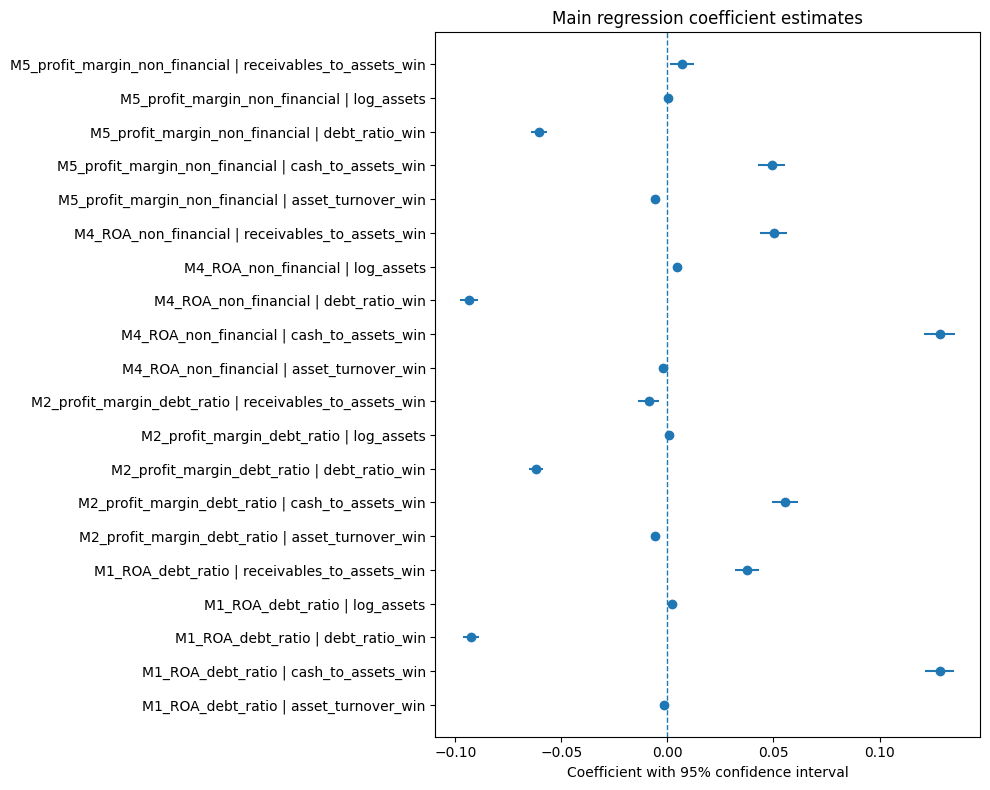

Saved data: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_10_coefficient_plot_data.csv


In [24]:
plot_vars = [
    "debt_ratio_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

plot_models = [
    "M1_ROA_debt_ratio",
    "M2_profit_margin_debt_ratio",
    "M4_ROA_non_financial",
    "M5_profit_margin_non_financial"
]

coef_plot_data = combined_results[
    combined_results["model"].isin(plot_models)
    & combined_results["variable"].isin(plot_vars)
].copy()

coef_plot_data["label"] = coef_plot_data["model"] + " | " + coef_plot_data["variable"]

coef_plot_data = coef_plot_data.sort_values(["model", "variable"])

plt.figure(figsize=(10, 8))

y_pos = np.arange(len(coef_plot_data))

plt.errorbar(
    coef_plot_data["coef"],
    y_pos,
    xerr=[
        coef_plot_data["coef"] - coef_plot_data["conf_low"],
        coef_plot_data["conf_high"] - coef_plot_data["coef"]
    ],
    fmt="o"
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.yticks(y_pos, coef_plot_data["label"])
plt.xlabel("Coefficient with 95% confidence interval")
plt.title("Main regression coefficient estimates")

save_fig("fig_01_main_regression_coefficient_plot")
plt.show()

coef_plot_path = os.path.join(OUT_DIR, "05_10_coefficient_plot_data.csv")
coef_plot_data.to_csv(coef_plot_path, index=False)

print("Saved data:", coef_plot_path)

**Cell 24 - Existing model comparison table**

In [25]:
existing_models = {
    "M1_ROA_debt_ratio": m1_roa,
    "M2_profit_margin_debt_ratio": m2_profit_margin,
    "M3_ROA_equity_ratio": m3_roa_equity
}

if "m4_roa_nonfin" in globals():
    existing_models["M4_ROA_non_financial"] = m4_roa_nonfin

if "m5_pm_nonfin" in globals():
    existing_models["M5_profit_margin_non_financial"] = m5_pm_nonfin


def model_metrics_table(model_dict):
    rows = []
    for name, model in model_dict.items():
        rows.append({
            "model": name,
            "nobs": int(model.nobs),
            "r_squared": model.rsquared,
            "adj_r_squared": model.rsquared_adj,
            "aic": model.aic,
            "bic": model.bic
        })
    return pd.DataFrame(rows).sort_values("adj_r_squared", ascending=False)


existing_model_comparison = model_metrics_table(existing_models)

existing_model_comparison_path = os.path.join(OUT_DIR, "05_11_existing_model_comparison.csv")
existing_model_comparison.to_csv(existing_model_comparison_path, index=False)

display(existing_model_comparison)

print("Saved:", existing_model_comparison_path)

,model,nobs,r_squared,adj_r_squared,aic,bic
4,M5_profit_margin_non_financial,61862,0.2673,0.2670,"-88,103.7833","-87,859.9015"
1,M2_profit_margin_debt_ratio,71275,0.2351,0.2348,"-92,721.6175","-92,464.7371"
2,M3_ROA_equity_ratio,72076,0.1308,0.1304,"-63,405.1506","-63,147.9572"
3,M4_ROA_non_financial,62222,0.1198,0.1194,"-58,154.4046","-57,910.3661"
0,M1_ROA_debt_ratio,71715,0.1152,0.1148,"-62,044.1918","-61,787.1391"


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_11_existing_model_comparison.csv


**Cell 25 - Detect WZ 4-digit column**

In [26]:
WZ4_COL = pick_col(["wz_code", "WZ_code", "wz_4digit", "wz4"])

print("WZ4_COL:", WZ4_COL)

if WZ4_COL is not None:
    print("Number of unique WZ 4-digit industries:")
    print(df[WZ4_COL].nunique(dropna=True))
else:
    print("WZ 4-digit column not found.")

WZ4_COL: wz_4digit
Number of unique WZ 4-digit industries:
428


**Cell 26 - Prepare grouped WZ 4-digit industry fixed effects**

In [27]:
if WZ4_COL is not None:
    model_df[WZ4_COL] = df[WZ4_COL]

    model_df["wz4_grouped"] = model_df[WZ4_COL].astype(str)

    wz4_counts = model_df["wz4_grouped"].value_counts()

    # Keep detailed WZ4 categories only if they have enough observations
    reliable_wz4 = wz4_counts[wz4_counts >= 500].index

    model_df["wz4_grouped"] = np.where(
        model_df["wz4_grouped"].isin(reliable_wz4),
        model_df["wz4_grouped"],
        "Other_or_small_WZ4"
    )

    model_df["wz4_grouped"] = model_df["wz4_grouped"].astype("category")

    wz4_group_summary = (
        model_df["wz4_grouped"]
        .value_counts()
        .reset_index()
    )

    wz4_group_summary.columns = ["wz4_grouped", "n"]

    wz4_group_path = os.path.join(OUT_DIR, "05_12_wz4_grouped_counts.csv")
    wz4_group_summary.to_csv(wz4_group_path, index=False)

    display(wz4_group_summary.head(20))
    print("Saved:", wz4_group_path)
else:
    print("Skipped because WZ4 column is not available.")

,wz4_grouped,n
0,Other_or_small_WZ4,10371
1,66.19,9571
2,71.12,8772
3,68.31,7778
4,66.22,3894
5,28.25,2935
6,71.11,2783
7,26.11,2589
8,45.19,2433
9,32.5,2403


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_12_wz4_grouped_counts.csv


**Cell 27 - Run WZ 4-digit fixed-effect models**

In [28]:
if WZ4_COL is not None:
    wz4_controls = " + log_assets + C(wz4_grouped)"

    if YEAR_COL is not None:
        wz4_controls += f" + C({YEAR_COL})"

    formula_m6 = (
        "roa_win ~ debt_ratio_win + cash_to_assets_win + "
        "receivables_to_assets_win + asset_turnover_win"
        + wz4_controls
    )

    formula_m7 = (
        "profit_margin_win ~ debt_ratio_win + cash_to_assets_win + "
        "receivables_to_assets_win + asset_turnover_win"
        + wz4_controls
    )

    m6_roa_wz4 = smf.ols(formula_m6, data=model_df).fit(cov_type="HC3")
    m7_pm_wz4 = smf.ols(formula_m7, data=model_df).fit(cov_type="HC3")

    print("M6 and M7 estimated.")
    print("\nM6 formula:")
    print(formula_m6)
    print("\nM7 formula:")
    print(formula_m7)

    wz4_model_comparison = model_metrics_table({
        "M1_ROA_sector_FE": m1_roa,
        "M2_PM_sector_FE": m2_profit_margin,
        "M6_ROA_WZ4_FE": m6_roa_wz4,
        "M7_PM_WZ4_FE": m7_pm_wz4
    })

    wz4_comparison_path = os.path.join(OUT_DIR, "05_13_wz4_model_comparison.csv")
    wz4_model_comparison.to_csv(wz4_comparison_path, index=False)

    display(wz4_model_comparison)
    print("Saved:", wz4_comparison_path)
else:
    print("Skipped because WZ4 column is not available.")

M6 and M7 estimated.

M6 formula:
roa_win ~ debt_ratio_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + log_assets + C(wz4_grouped) + C(financial_year)

M7 formula:
profit_margin_win ~ debt_ratio_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + log_assets + C(wz4_grouped) + C(financial_year)


,model,nobs,r_squared,adj_r_squared,aic,bic
3,M7_PM_WZ4_FE,71302,0.3051,0.3046,"-99,280.7120","-98,812.8034"
1,M2_PM_sector_FE,71275,0.2351,0.2348,"-92,721.6175","-92,464.7371"
2,M6_ROA_WZ4_FE,71745,0.1302,0.1296,"-63,257.2719","-62,789.0474"
0,M1_ROA_sector_FE,71715,0.1152,0.1148,"-62,044.1918","-61,787.1391"


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_13_wz4_model_comparison.csv


**Cell 28 - Run non-linear and interaction models**

In [29]:
nonlinear_controls = " + log_assets + I(log_assets ** 2)"

if SECTOR_COL is not None:
    nonlinear_controls += f" + C({SECTOR_COL})"

if YEAR_COL is not None:
    nonlinear_controls += f" + C({YEAR_COL})"


formula_m8 = (
    "roa_win ~ debt_ratio_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win + "
    "debt_ratio_win:cash_to_assets_win"
    + nonlinear_controls
)

formula_m9 = (
    "profit_margin_win ~ debt_ratio_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win + "
    "debt_ratio_win:cash_to_assets_win"
    + nonlinear_controls
)

m8_roa_nonlinear = smf.ols(formula_m8, data=model_df).fit(cov_type="HC3")
m9_pm_nonlinear = smf.ols(formula_m9, data=model_df).fit(cov_type="HC3")

print("M8 and M9 estimated.")

print("\nM8 formula:")
print(formula_m8)

print("\nM9 formula:")
print(formula_m9)

nonlinear_model_comparison = model_metrics_table({
    "M1_ROA_basic": m1_roa,
    "M2_PM_basic": m2_profit_margin,
    "M8_ROA_nonlinear_interaction": m8_roa_nonlinear,
    "M9_PM_nonlinear_interaction": m9_pm_nonlinear
})

nonlinear_comparison_path = os.path.join(OUT_DIR, "05_14_nonlinear_model_comparison.csv")
nonlinear_model_comparison.to_csv(nonlinear_comparison_path, index=False)

display(nonlinear_model_comparison)

print("Saved:", nonlinear_comparison_path)

M8 and M9 estimated.

M8 formula:
roa_win ~ debt_ratio_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + debt_ratio_win:cash_to_assets_win + log_assets + I(log_assets ** 2) + C(wz_section) + C(financial_year)

M9 formula:
profit_margin_win ~ debt_ratio_win + cash_to_assets_win + receivables_to_assets_win + asset_turnover_win + debt_ratio_win:cash_to_assets_win + log_assets + I(log_assets ** 2) + C(wz_section) + C(financial_year)


,model,nobs,r_squared,adj_r_squared,aic,bic
3,M9_PM_nonlinear_interaction,71275,0.2427,0.2424,"-93,427.2932","-93,152.0641"
1,M2_PM_basic,71275,0.2351,0.2348,"-92,721.6175","-92,464.7371"
2,M8_ROA_nonlinear_interaction,71715,0.1260,0.1256,"-62,922.2438","-62,646.8301"
0,M1_ROA_basic,71715,0.1152,0.1148,"-62,044.1918","-61,787.1391"


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_14_nonlinear_model_comparison.csv


**Cell 29 - Combined comparison of all models**

In [30]:
all_models_for_comparison = {
    "M1_ROA_sector_FE": m1_roa,
    "M2_PM_sector_FE": m2_profit_margin,
    "M3_ROA_equity_sector_FE": m3_roa_equity,
    "M8_ROA_nonlinear_interaction": m8_roa_nonlinear,
    "M9_PM_nonlinear_interaction": m9_pm_nonlinear
}

if "m4_roa_nonfin" in globals():
    all_models_for_comparison["M4_ROA_nonfinancial"] = m4_roa_nonfin

if "m5_pm_nonfin" in globals():
    all_models_for_comparison["M5_PM_nonfinancial"] = m5_pm_nonfin

if "m6_roa_wz4" in globals():
    all_models_for_comparison["M6_ROA_WZ4_FE"] = m6_roa_wz4

if "m7_pm_wz4" in globals():
    all_models_for_comparison["M7_PM_WZ4_FE"] = m7_pm_wz4


all_model_comparison = model_metrics_table(all_models_for_comparison)

all_model_comparison_path = os.path.join(OUT_DIR, "05_15_all_model_comparison.csv")
all_model_comparison.to_csv(all_model_comparison_path, index=False)

display(all_model_comparison)

print("Saved:", all_model_comparison_path)

,model,nobs,r_squared,adj_r_squared,aic,bic
8,M7_PM_WZ4_FE,71302,0.3051,0.3046,"-99,280.7120","-98,812.8034"
6,M5_PM_nonfinancial,61862,0.2673,0.2670,"-88,103.7833","-87,859.9015"
4,M9_PM_nonlinear_interaction,71275,0.2427,0.2424,"-93,427.2932","-93,152.0641"
1,M2_PM_sector_FE,71275,0.2351,0.2348,"-92,721.6175","-92,464.7371"
2,M3_ROA_equity_sector_FE,72076,0.1308,0.1304,"-63,405.1506","-63,147.9572"
7,M6_ROA_WZ4_FE,71745,0.1302,0.1296,"-63,257.2719","-62,789.0474"
3,M8_ROA_nonlinear_interaction,71715,0.1260,0.1256,"-62,922.2438","-62,646.8301"
5,M4_ROA_nonfinancial,62222,0.1198,0.1194,"-58,154.4046","-57,910.3661"
0,M1_ROA_sector_FE,71715,0.1152,0.1148,"-62,044.1918","-61,787.1391"


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_15_all_model_comparison.csv


**Cell 30 - Extract key results from improved models**

In [31]:
improved_results_list = []

if "m6_roa_wz4" in globals():
    improved_results_list.append(
        extract_key_results(m6_roa_wz4, "M6_ROA_WZ4_FE", key_vars_m1_m2)
    )

if "m7_pm_wz4" in globals():
    improved_results_list.append(
        extract_key_results(m7_pm_wz4, "M7_PM_WZ4_FE", key_vars_m1_m2)
    )

interaction_key_vars = [
    "debt_ratio_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "debt_ratio_win:cash_to_assets_win",
    "log_assets",
    "I(log_assets ** 2)"
]

improved_results_list.append(
    extract_key_results(m8_roa_nonlinear, "M8_ROA_nonlinear_interaction", interaction_key_vars)
)

improved_results_list.append(
    extract_key_results(m9_pm_nonlinear, "M9_PM_nonlinear_interaction", interaction_key_vars)
)

improved_results = pd.concat(improved_results_list, ignore_index=True)

improved_results_path = os.path.join(OUT_DIR, "05_16_improved_model_key_results.csv")
improved_results.to_csv(improved_results_path, index=False)

display(improved_results)

print("Saved:", improved_results_path)

,model,variable,coef,std_error,t_value,p_value,conf_low,conf_high,nobs,r_squared,adj_r_squared
0,M6_ROA_WZ4_FE,debt_ratio_win,-0.0888,0.0020,-44.9941,0.0000,-0.0927,-0.0850,71745,0.1302,0.1296
1,M6_ROA_WZ4_FE,cash_to_assets_win,0.1362,0.0036,38.1347,0.0000,0.1292,0.1432,71745,0.1302,0.1296
2,M6_ROA_WZ4_FE,receivables_to_assets_win,0.0502,0.0031,16.2007,0.0000,0.0442,0.0563,71745,0.1302,0.1296
3,M6_ROA_WZ4_FE,asset_turnover_win,-0.0034,0.0003,-12.4049,0.0000,-0.0040,-0.0029,71745,0.1302,0.1296
4,M6_ROA_WZ4_FE,log_assets,-0.0008,0.0005,-1.6052,0.1085,-0.0018,0.0002,71745,0.1302,0.1296
5,M7_PM_WZ4_FE,debt_ratio_win,-0.0582,0.0017,-34.4160,0.0000,-0.0615,-0.0549,71302,0.3051,0.3046
6,M7_PM_WZ4_FE,cash_to_assets_win,0.0603,0.0030,20.1087,0.0000,0.0544,0.0661,71302,0.3051,0.3046
7,M7_PM_WZ4_FE,receivables_to_assets_win,0.0022,0.0025,0.8969,0.3698,-0.0027,0.0072,71302,0.3051,0.3046
8,M7_PM_WZ4_FE,asset_turnover_win,-0.0081,0.0002,-39.4045,0.0000,-0.0086,-0.0077,71302,0.3051,0.3046
9,M7_PM_WZ4_FE,log_assets,-0.0041,0.0004,-9.6063,0.0000,-0.0049,-0.0033,71302,0.3051,0.3046


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_16_improved_model_key_results.csv


**Cell 31 - Save final model decision helper**

In [32]:
best_models = (
    all_model_comparison
    .sort_values("adj_r_squared", ascending=False)
    .reset_index(drop=True)
)

decision_note = """
Model decision rule:

1. Do not select a model only because R-squared is higher.
2. Prefer adjusted R-squared over raw R-squared.
3. Prefer models that are theoretically meaningful and easy to explain.
4. If WZ4 fixed effects improve adjusted R-squared clearly, use them as an extended model.
5. Keep the sector fixed-effect model as the main baseline because it is easier to interpret.
6. Use WZ4 fixed effects and non-linear/interactions as robustness or extended specifications.
7. Random Forest or ML models can improve prediction, but they are less suitable as the main thesis model if the goal is interpretation.

Recommended structure:
- Main model: sector fixed effects
- Extended model: WZ4 fixed effects
- Robustness model: excluding financial-sector firms
- Optional extension: non-linear and interaction model
"""

decision_path = os.path.join(OUT_DIR, "05_17_model_decision_note.txt")

with open(decision_path, "w") as f:
    f.write(decision_note)

display(best_models)

print(decision_note)
print("Saved:", decision_path)

,model,nobs,r_squared,adj_r_squared,aic,bic
0,M7_PM_WZ4_FE,71302,0.3051,0.3046,"-99,280.7120","-98,812.8034"
1,M5_PM_nonfinancial,61862,0.2673,0.2670,"-88,103.7833","-87,859.9015"
2,M9_PM_nonlinear_interaction,71275,0.2427,0.2424,"-93,427.2932","-93,152.0641"
3,M2_PM_sector_FE,71275,0.2351,0.2348,"-92,721.6175","-92,464.7371"
4,M3_ROA_equity_sector_FE,72076,0.1308,0.1304,"-63,405.1506","-63,147.9572"
5,M6_ROA_WZ4_FE,71745,0.1302,0.1296,"-63,257.2719","-62,789.0474"
6,M8_ROA_nonlinear_interaction,71715,0.1260,0.1256,"-62,922.2438","-62,646.8301"
7,M4_ROA_nonfinancial,62222,0.1198,0.1194,"-58,154.4046","-57,910.3661"
8,M1_ROA_sector_FE,71715,0.1152,0.1148,"-62,044.1918","-61,787.1391"



Model decision rule:

1. Do not select a model only because R-squared is higher.
2. Prefer adjusted R-squared over raw R-squared.
3. Prefer models that are theoretically meaningful and easy to explain.
4. If WZ4 fixed effects improve adjusted R-squared clearly, use them as an extended model.
5. Keep the sector fixed-effect model as the main baseline because it is easier to interpret.
6. Use WZ4 fixed effects and non-linear/interactions as robustness or extended specifications.
7. Random Forest or ML models can improve prediction, but they are less suitable as the main thesis model if the goal is interpretation.

Recommended structure:
- Main model: sector fixed effects
- Extended model: WZ4 fixed effects
- Robustness model: excluding financial-sector firms
- Optional extension: non-linear and interaction model

Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05_17_model_decision_note.txt


In [35]:
# ============================================================
# Cell 32 — Model stability output folder
# ============================================================

STABILITY_DIR = os.path.join(OUT_DIR, "05B_model_stability_checks")
os.makedirs(STABILITY_DIR, exist_ok=True)

print("Model stability output folder:")
print(STABILITY_DIR)

Model stability output folder:
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05B_model_stability_checks


In [36]:
# ============================================================
# Cell 33 — Same-sample comparison for profit margin models
# ============================================================

pm_common_vars = [
    "profit_margin_win",
    "debt_ratio_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

for col in [YEAR_COL, SECTOR_COL]:
    if col is not None:
        pm_common_vars.append(col)

if "wz4_grouped" in model_df.columns:
    pm_common_vars.append("wz4_grouped")

pm_common_vars = list(dict.fromkeys(pm_common_vars))

pm_common_df = model_df[pm_common_vars].dropna().copy()

print("Profit margin common sample rows:", pm_common_df.shape[0])

# Sector FE model on common sample
pm_sector_formula_common = (
    "profit_margin_win ~ debt_ratio_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win + log_assets"
)

if SECTOR_COL is not None:
    pm_sector_formula_common += f" + C({SECTOR_COL})"

if YEAR_COL is not None:
    pm_sector_formula_common += f" + C({YEAR_COL})"


# WZ4 FE model on common sample
pm_wz4_formula_common = (
    "profit_margin_win ~ debt_ratio_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win + log_assets"
)

if "wz4_grouped" in pm_common_df.columns:
    pm_wz4_formula_common += " + C(wz4_grouped)"

if YEAR_COL is not None:
    pm_wz4_formula_common += f" + C({YEAR_COL})"


# WZ4 + non-linear/interactions on common sample
pm_wz4_plus_formula_common = (
    "profit_margin_win ~ debt_ratio_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win + "
    "debt_ratio_win:cash_to_assets_win + log_assets + I(log_assets ** 2)"
)

if "wz4_grouped" in pm_common_df.columns:
    pm_wz4_plus_formula_common += " + C(wz4_grouped)"

if YEAR_COL is not None:
    pm_wz4_plus_formula_common += f" + C({YEAR_COL})"


pm_sector_common = smf.ols(pm_sector_formula_common, data=pm_common_df).fit(cov_type="HC3")
pm_wz4_common = smf.ols(pm_wz4_formula_common, data=pm_common_df).fit(cov_type="HC3")
pm_wz4_plus_common = smf.ols(pm_wz4_plus_formula_common, data=pm_common_df).fit(cov_type="HC3")

same_sample_pm_comparison = model_metrics_table({
    "PM_sector_FE_common_sample": pm_sector_common,
    "PM_WZ4_FE_common_sample": pm_wz4_common,
    "PM_WZ4_plus_common_sample": pm_wz4_plus_common
})

same_sample_pm_path = os.path.join(STABILITY_DIR, "05B_01_same_sample_pm_model_comparison.csv")
same_sample_pm_comparison.to_csv(same_sample_pm_path, index=False)

display(same_sample_pm_comparison)

print("Saved:", same_sample_pm_path)

Profit margin common sample rows: 71275


,model,nobs,r_squared,adj_r_squared,aic,bic
2,PM_WZ4_plus_common_sample,71275,0.3107,0.3102,"-100,089.6769","-99,603.4389"
1,PM_WZ4_FE_common_sample,71275,0.3053,0.3048,"-99,534.7088","-99,066.8195"
0,PM_sector_FE_common_sample,71275,0.2351,0.2348,"-92,721.6175","-92,464.7371"


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05B_model_stability_checks/05B_01_same_sample_pm_model_comparison.csv


In [37]:
# ============================================================
# Cell 34 — Same-sample comparison for ROA models
# ============================================================

roa_common_vars = [
    "roa_win",
    "debt_ratio_win",
    "equity_ratio_calc_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

for col in [YEAR_COL, SECTOR_COL]:
    if col is not None:
        roa_common_vars.append(col)

if "wz4_grouped" in model_df.columns:
    roa_common_vars.append("wz4_grouped")

roa_common_vars = list(dict.fromkeys(roa_common_vars))

roa_common_df = model_df[roa_common_vars].dropna().copy()

print("ROA common sample rows:", roa_common_df.shape[0])

roa_debt_sector_formula_common = (
    "roa_win ~ debt_ratio_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win + log_assets"
)

if SECTOR_COL is not None:
    roa_debt_sector_formula_common += f" + C({SECTOR_COL})"

if YEAR_COL is not None:
    roa_debt_sector_formula_common += f" + C({YEAR_COL})"


roa_equity_sector_formula_common = (
    "roa_win ~ equity_ratio_calc_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win + log_assets"
)

if SECTOR_COL is not None:
    roa_equity_sector_formula_common += f" + C({SECTOR_COL})"

if YEAR_COL is not None:
    roa_equity_sector_formula_common += f" + C({YEAR_COL})"


roa_wz4_formula_common = (
    "roa_win ~ debt_ratio_win + cash_to_assets_win + "
    "receivables_to_assets_win + asset_turnover_win + log_assets"
)

if "wz4_grouped" in roa_common_df.columns:
    roa_wz4_formula_common += " + C(wz4_grouped)"

if YEAR_COL is not None:
    roa_wz4_formula_common += f" + C({YEAR_COL})"


roa_debt_sector_common = smf.ols(roa_debt_sector_formula_common, data=roa_common_df).fit(cov_type="HC3")
roa_equity_sector_common = smf.ols(roa_equity_sector_formula_common, data=roa_common_df).fit(cov_type="HC3")
roa_wz4_common = smf.ols(roa_wz4_formula_common, data=roa_common_df).fit(cov_type="HC3")

same_sample_roa_comparison = model_metrics_table({
    "ROA_debt_sector_FE_common_sample": roa_debt_sector_common,
    "ROA_equity_sector_FE_common_sample": roa_equity_sector_common,
    "ROA_WZ4_FE_common_sample": roa_wz4_common
})

same_sample_roa_path = os.path.join(STABILITY_DIR, "05B_02_same_sample_roa_model_comparison.csv")
same_sample_roa_comparison.to_csv(same_sample_roa_path, index=False)

display(same_sample_roa_comparison)

print("Saved:", same_sample_roa_path)

ROA common sample rows: 71505


,model,nobs,r_squared,adj_r_squared,aic,bic
1,ROA_equity_sector_FE_common_sample,71505,0.1318,0.1314,"-63,487.3091","-63,230.3385"
2,ROA_WZ4_FE_common_sample,71505,0.1300,0.1294,"-63,294.5681","-62,826.5145"
0,ROA_debt_sector_FE_common_sample,71505,0.1148,0.1145,"-62,102.3979","-61,845.4273"


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05B_model_stability_checks/05B_02_same_sample_roa_model_comparison.csv


In [38]:
# ============================================================
# Cell 35 — Coefficient stability across profit margin models
# ============================================================

key_pm_vars = [
    "debt_ratio_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

pm_stability_models = {
    "PM_sector_FE": pm_sector_common,
    "PM_WZ4_FE": pm_wz4_common,
    "PM_WZ4_plus": pm_wz4_plus_common
}

pm_coef_stability = []

for model_name, model in pm_stability_models.items():
    for var in key_pm_vars:
        if var in model.params.index:
            pm_coef_stability.append({
                "model": model_name,
                "variable": var,
                "coef": model.params[var],
                "std_error": model.bse[var],
                "p_value": model.pvalues[var],
                "direction": "positive" if model.params[var] > 0 else "negative",
                "significant_5pct": model.pvalues[var] < 0.05
            })

pm_coef_stability = pd.DataFrame(pm_coef_stability)

pm_coef_stability_path = os.path.join(STABILITY_DIR, "05B_03_pm_coefficient_stability.csv")
pm_coef_stability.to_csv(pm_coef_stability_path, index=False)

display(pm_coef_stability)

print("Saved:", pm_coef_stability_path)

,model,variable,coef,std_error,p_value,direction,significant_5pct
0,PM_sector_FE,debt_ratio_win,-0.0620,0.0018,0.0000,negative,True
1,PM_sector_FE,cash_to_assets_win,0.0552,0.0031,0.0000,positive,True
2,PM_sector_FE,receivables_to_assets_win,-0.0088,0.0025,0.0005,negative,True
3,PM_sector_FE,asset_turnover_win,-0.0058,0.0001,0.0000,negative,True
4,PM_sector_FE,log_assets,0.0005,0.0004,0.1690,positive,False
5,PM_WZ4_FE,debt_ratio_win,-0.0579,0.0017,0.0000,negative,True
6,PM_WZ4_FE,cash_to_assets_win,0.0607,0.0030,0.0000,positive,True
7,PM_WZ4_FE,receivables_to_assets_win,0.0026,0.0025,0.2979,positive,False
8,PM_WZ4_FE,asset_turnover_win,-0.0081,0.0002,0.0000,negative,True
9,PM_WZ4_FE,log_assets,-0.0041,0.0004,0.0000,negative,True


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05B_model_stability_checks/05B_03_pm_coefficient_stability.csv


In [39]:
# ============================================================
# Cell 36 — Cluster-robust standard errors for best PM model
# ============================================================

if "wz4_grouped" in pm_common_df.columns:
    cluster_group = pm_common_df["wz4_grouped"]
    cluster_label = "wz4_grouped"
elif SECTOR_COL is not None:
    cluster_group = pm_common_df[SECTOR_COL]
    cluster_label = SECTOR_COL
else:
    cluster_group = None
    cluster_label = None

if cluster_group is not None:
    pm_wz4_cluster = smf.ols(
        pm_wz4_formula_common,
        data=pm_common_df
    ).fit(
        cov_type="cluster",
        cov_kwds={"groups": cluster_group}
    )

    cluster_compare = []

    for var in key_pm_vars:
        if var in pm_wz4_common.params.index and var in pm_wz4_cluster.params.index:
            cluster_compare.append({
                "variable": var,
                "coef_HC3": pm_wz4_common.params[var],
                "se_HC3": pm_wz4_common.bse[var],
                "p_HC3": pm_wz4_common.pvalues[var],
                "coef_cluster": pm_wz4_cluster.params[var],
                "se_cluster": pm_wz4_cluster.bse[var],
                "p_cluster": pm_wz4_cluster.pvalues[var]
            })

    cluster_compare = pd.DataFrame(cluster_compare)

    cluster_path = os.path.join(STABILITY_DIR, "05B_04_cluster_robust_pm_wz4_results.csv")
    cluster_compare.to_csv(cluster_path, index=False)

    print("Cluster variable:", cluster_label)
    display(cluster_compare)
    print("Saved:", cluster_path)
else:
    print("No cluster variable available.")

Cluster variable: wz4_grouped


,variable,coef_HC3,se_HC3,p_HC3,coef_cluster,se_cluster,p_cluster
0,debt_ratio_win,-0.0579,0.0017,0.0000,-0.0579,0.0091,0.0000
1,cash_to_assets_win,0.0607,0.0030,0.0000,0.0607,0.0105,0.0000
2,receivables_to_assets_win,0.0026,0.0025,0.2979,0.0026,0.0123,0.8318
3,asset_turnover_win,-0.0081,0.0002,0.0000,-0.0081,0.0027,0.0026
4,log_assets,-0.0041,0.0004,0.0000,-0.0041,0.0030,0.1734


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05B_model_stability_checks/05B_04_cluster_robust_pm_wz4_results.csv


In [40]:
# ============================================================
# Cell 37 — Leave-one-year-out stability check for PM WZ4 model
# ============================================================

if YEAR_COL is not None and "wz4_grouped" in pm_common_df.columns:
    leave_year_results = []

    years = sorted(pm_common_df[YEAR_COL].dropna().unique())

    for y in years:
        temp_df = pm_common_df[pm_common_df[YEAR_COL] != y].copy()

        temp_model = smf.ols(
            pm_wz4_formula_common,
            data=temp_df
        ).fit(cov_type="HC3")

        for var in key_pm_vars:
            if var in temp_model.params.index:
                leave_year_results.append({
                    "excluded_year": y,
                    "variable": var,
                    "coef": temp_model.params[var],
                    "p_value": temp_model.pvalues[var],
                    "adj_r_squared": temp_model.rsquared_adj,
                    "nobs": int(temp_model.nobs)
                })

    leave_year_results = pd.DataFrame(leave_year_results)

    leave_year_path = os.path.join(STABILITY_DIR, "05B_05_leave_one_year_out_pm_wz4.csv")
    leave_year_results.to_csv(leave_year_path, index=False)

    display(leave_year_results)
    print("Saved:", leave_year_path)
else:
    print("Skipped because YEAR_COL or wz4_grouped is not available.")

,excluded_year,variable,coef,p_value,adj_r_squared,nobs
0,"2,020.0000",debt_ratio_win,-0.0588,0.0000,0.3083,68774
1,"2,020.0000",cash_to_assets_win,0.0615,0.0000,0.3083,68774
2,"2,020.0000",receivables_to_assets_win,0.0026,0.3158,0.3083,68774
3,"2,020.0000",asset_turnover_win,-0.0084,0.0000,0.3083,68774
4,"2,020.0000",log_assets,-0.0042,0.0000,0.3083,68774
5,"2,021.0000",debt_ratio_win,-0.0576,0.0000,0.3118,67329
6,"2,021.0000",cash_to_assets_win,0.0634,0.0000,0.3118,67329
7,"2,021.0000",receivables_to_assets_win,0.0054,0.0367,0.3118,67329
8,"2,021.0000",asset_turnover_win,-0.0082,0.0000,0.3118,67329
9,"2,021.0000",log_assets,-0.0044,0.0000,0.3118,67329


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05B_model_stability_checks/05B_05_leave_one_year_out_pm_wz4.csv


In [41]:
# ============================================================
# Cell 38 — Summarise leave-one-year-out stability
# ============================================================

if "leave_year_results" in globals() and isinstance(leave_year_results, pd.DataFrame) and not leave_year_results.empty:
    leave_year_summary = (
        leave_year_results
        .groupby("variable")
        .agg(
            coef_min=("coef", "min"),
            coef_max=("coef", "max"),
            mean_coef=("coef", "mean"),
            always_significant_5pct=("p_value", lambda x: bool((x < 0.05).all())),
            min_adj_r_squared=("adj_r_squared", "min"),
            max_adj_r_squared=("adj_r_squared", "max")
        )
        .reset_index()
    )

    leave_year_summary_path = os.path.join(STABILITY_DIR, "05B_06_leave_one_year_out_summary.csv")
    leave_year_summary.to_csv(leave_year_summary_path, index=False)

    display(leave_year_summary)
    print("Saved:", leave_year_summary_path)
else:
    print("Leave-one-year-out results not available.")

,variable,coef_min,coef_max,mean_coef,always_significant_5pct,min_adj_r_squared,max_adj_r_squared
0,asset_turnover_win,-0.0084,-0.0074,-0.0081,True,0.2844,0.3118
1,cash_to_assets_win,0.0496,0.0634,0.0594,True,0.2844,0.3118
2,debt_ratio_win,-0.0601,-0.0567,-0.0582,True,0.2844,0.3118
3,log_assets,-0.0044,-0.0033,-0.0041,True,0.2844,0.3118
4,receivables_to_assets_win,-0.0064,0.0054,0.0016,False,0.2844,0.3118


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05B_model_stability_checks/05B_06_leave_one_year_out_summary.csv


In [42]:
# ============================================================
# Cell 39 — Final model classification for thesis
# ============================================================

final_model_choice = pd.DataFrame([
    {
        "role": "Main baseline model",
        "model": "M2_PM_sector_FE",
        "reason": "Simple, interpretable model using broad industry and year controls.",
        "use_in_thesis": "Main profitability regression"
    },
    {
        "role": "Best explanatory model",
        "model": "M7_PM_WZ4_FE",
        "reason": "Highest adjusted R-squared; captures detailed industry heterogeneity.",
        "use_in_thesis": "Extended industry fixed-effect model"
    },
    {
        "role": "Robustness check",
        "model": "M5_PM_nonfinancial",
        "reason": "Tests whether results remain stable after excluding financial-sector firms.",
        "use_in_thesis": "Robustness/sensitivity subsection"
    },
    {
        "role": "Secondary outcome model",
        "model": "M3_ROA_equity_sector_FE",
        "reason": "Uses ROA as alternative profitability outcome and equity ratio instead of debt ratio.",
        "use_in_thesis": "Secondary profitability model"
    },
    {
        "role": "Optional appendix model",
        "model": "M9_PM_nonlinear_interaction",
        "reason": "Tests non-linear size and debt-liquidity interaction, but improvement is smaller than WZ4 FE.",
        "use_in_thesis": "Optional appendix or brief sensitivity check"
    }
])

final_choice_path = os.path.join(STABILITY_DIR, "05B_07_final_model_classification.csv")
final_model_choice.to_csv(final_choice_path, index=False)

display(final_model_choice)

print("Saved:", final_choice_path)

,role,model,reason,use_in_thesis
0,Main baseline model,M2_PM_sector_FE,"Simple, interpretable model using broad indust...",Main profitability regression
1,Best explanatory model,M7_PM_WZ4_FE,Highest adjusted R-squared; captures detailed ...,Extended industry fixed-effect model
2,Robustness check,M5_PM_nonfinancial,Tests whether results remain stable after excl...,Robustness/sensitivity subsection
3,Secondary outcome model,M3_ROA_equity_sector_FE,Uses ROA as alternative profitability outcome ...,Secondary profitability model
4,Optional appendix model,M9_PM_nonlinear_interaction,Tests non-linear size and debt-liquidity inter...,Optional appendix or brief sensitivity check


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05B_model_stability_checks/05B_07_final_model_classification.csv


In [43]:
# ============================================================
# Cell 40 — Save thesis notes for model stability section
# ============================================================

stability_notes = """
MODEL STABILITY NOTES FOR THESIS

The econometric analysis first estimated baseline OLS models with HC3 robust standard errors.
Profit margin and ROA were used as profitability outcomes. The baseline models included
financial structure variables, firm size, WZ sector fixed effects, and year fixed effects.

The model comparison showed that profit margin models have stronger explanatory power than
ROA models. The best model was the profit margin model with grouped WZ 4-digit fixed effects.
This indicates that detailed industry heterogeneity explains an important part of profitability
differences across German firms.

Model stability was checked in four ways:

1. Same-sample comparison:
Models were re-estimated on identical observations to make sure differences in adjusted R-squared
were not only caused by different sample sizes.

2. Coefficient stability:
The signs and significance of key explanatory variables were compared across sector fixed-effect,
WZ4 fixed-effect, and non-linear/interaction specifications.

3. Cluster-robust standard errors:
The best profit margin model was re-estimated with standard errors clustered by industry group.
This checks whether the main results remain stable when observations within the same industry
are allowed to have correlated errors.

4. Leave-one-year-out check:
The best profit margin model was re-estimated after excluding one financial year at a time.
This checks whether the results are overly dependent on a single year, especially 2023.

Overall model interpretation:
Higher leverage is expected to be negatively associated with profitability, while stronger liquidity
is expected to be positively associated with profitability. Detailed industry controls improve model
fit substantially, showing that profitability differences are strongly industry-specific.

Recommended thesis model structure:
- Main baseline model: Profit margin with WZ section and year fixed effects.
- Extended model: Profit margin with grouped WZ 4-digit and year fixed effects.
- Robustness model: Profit margin excluding financial-sector firms.
- Secondary outcome model: ROA with equity ratio and sector/year fixed effects.
"""

stability_notes_path = os.path.join(STABILITY_DIR, "05B_08_model_stability_notes_for_thesis.txt")

with open(stability_notes_path, "w") as f:
    f.write(stability_notes)

print(stability_notes)
print("Saved:", stability_notes_path)


MODEL STABILITY NOTES FOR THESIS

The econometric analysis first estimated baseline OLS models with HC3 robust standard errors.
Profit margin and ROA were used as profitability outcomes. The baseline models included
financial structure variables, firm size, WZ sector fixed effects, and year fixed effects.

The model comparison showed that profit margin models have stronger explanatory power than
ROA models. The best model was the profit margin model with grouped WZ 4-digit fixed effects.
This indicates that detailed industry heterogeneity explains an important part of profitability
differences across German firms.

Model stability was checked in four ways:

1. Same-sample comparison:
Models were re-estimated on identical observations to make sure differences in adjusted R-squared
were not only caused by different sample sizes.

2. Coefficient stability:
The signs and significance of key explanatory variables were compared across sector fixed-effect,
WZ4 fixed-effect, and non-linear/in

**Cell 41 - Final selected regrassion table**

In [44]:
# ============================================================
# Cell 41 — Final selected regression table for thesis
# ============================================================

FINAL_DIR = os.path.join(OUT_DIR, "05C_final_regression_outputs")
os.makedirs(FINAL_DIR, exist_ok=True)

selected_vars = [
    "debt_ratio_win",
    "cash_to_assets_win",
    "receivables_to_assets_win",
    "asset_turnover_win",
    "log_assets"
]

var_labels = {
    "debt_ratio_win": "Debt ratio",
    "cash_to_assets_win": "Cash-to-assets",
    "receivables_to_assets_win": "Receivables-to-assets",
    "asset_turnover_win": "Asset turnover",
    "log_assets": "Log assets"
}

def sig_stars(p):
    if p < 0.01:
        return "***"
    elif p < 0.05:
        return "**"
    elif p < 0.10:
        return "*"
    else:
        return ""

def formatted_model_column(model, variables):
    output = {}

    for var in variables:
        label = var_labels.get(var, var)

        if var in model.params.index:
            coef = model.params[var]
            se = model.bse[var]
            p = model.pvalues[var]
            output[label] = f"{coef:.4f}{sig_stars(p)}\n({se:.4f})"
        else:
            output[label] = ""

    output["Observations"] = f"{int(model.nobs):,}"
    output["R-squared"] = f"{model.rsquared:.4f}"
    output["Adjusted R-squared"] = f"{model.rsquared_adj:.4f}"

    return pd.Series(output)

final_reg_table = pd.DataFrame({
    "M2 PM Sector FE": formatted_model_column(m2_profit_margin, selected_vars),
    "M7 PM WZ4 FE": formatted_model_column(m7_pm_wz4, selected_vars),
    "M5 PM Non-financial": formatted_model_column(m5_pm_nonfin, selected_vars)
})

# Add model information rows
final_reg_table.loc["Year fixed effects"] = ["Yes", "Yes", "Yes"]
final_reg_table.loc["Industry fixed effects"] = ["WZ section", "Grouped WZ4", "WZ section"]
final_reg_table.loc["Robust standard errors"] = ["HC3", "HC3", "HC3"]

final_reg_path = os.path.join(FINAL_DIR, "05C_01_final_selected_regression_table.csv")
final_reg_table.to_csv(final_reg_path)

display(final_reg_table)

print("Saved:", final_reg_path)

,M2 PM Sector FE,M7 PM WZ4 FE,M5 PM Non-financial
Debt ratio,-0.0620***\n(0.0018),-0.0582***\n(0.0017),-0.0607***\n(0.0019)
Cash-to-assets,0.0552***\n(0.0031),0.0603***\n(0.0030),0.0492***\n(0.0032)
Receivables-to-assets,-0.0088***\n(0.0025),0.0022\n(0.0025),0.0069**\n(0.0029)
Asset turnover,-0.0058***\n(0.0001),-0.0081***\n(0.0002),-0.0060***\n(0.0002)
Log assets,0.0005\n(0.0004),-0.0041***\n(0.0004),0.0004\n(0.0004)
Observations,"71,275","71,302","61,862"
R-squared,0.2351,0.3051,0.2673
Adjusted R-squared,0.2348,0.3046,0.2670
Year fixed effects,Yes,Yes,Yes
Industry fixed effects,WZ section,Grouped WZ4,WZ section


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05C_final_regression_outputs/05C_01_final_selected_regression_table.csv


In [45]:
# ============================================================
# Cell 42 — Cluster-robust final table for best model
# ============================================================

if "pm_wz4_cluster" in globals():
    cluster_final_table = pd.DataFrame({
        "variable": selected_vars,
        "label": [var_labels.get(v, v) for v in selected_vars],
        "coef": [pm_wz4_cluster.params[v] if v in pm_wz4_cluster.params.index else np.nan for v in selected_vars],
        "cluster_se": [pm_wz4_cluster.bse[v] if v in pm_wz4_cluster.bse.index else np.nan for v in selected_vars],
        "p_value": [pm_wz4_cluster.pvalues[v] if v in pm_wz4_cluster.pvalues.index else np.nan for v in selected_vars]
    })

    cluster_final_table["significance"] = cluster_final_table["p_value"].apply(sig_stars)

    cluster_final_path = os.path.join(FINAL_DIR, "05C_02_M7_cluster_robust_final_table.csv")
    cluster_final_table.to_csv(cluster_final_path, index=False)

    display(cluster_final_table)
    print("Saved:", cluster_final_path)
else:
    print("Cluster-robust model not found. Run Cell 36 first.")

,variable,label,coef,cluster_se,p_value,significance
0,debt_ratio_win,Debt ratio,-0.0579,0.0091,0.0000,***
1,cash_to_assets_win,Cash-to-assets,0.0607,0.0105,0.0000,***
2,receivables_to_assets_win,Receivables-to-assets,0.0026,0.0123,0.8318,
3,asset_turnover_win,Asset turnover,-0.0081,0.0027,0.0026,***
4,log_assets,Log assets,-0.0041,0.0030,0.1734,


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05C_final_regression_outputs/05C_02_M7_cluster_robust_final_table.csv


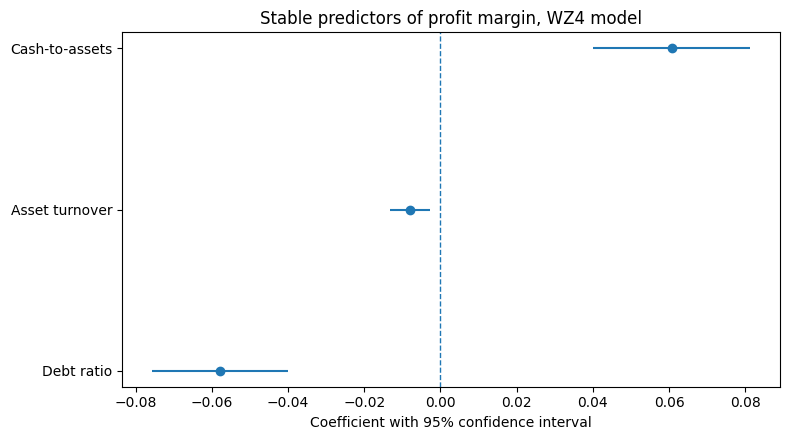

Saved:
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05C_final_regression_outputs/figures/05C_fig_01_stable_predictors_profit_margin.png
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05C_final_regression_outputs/figures/05C_fig_01_stable_predictors_profit_margin.pdf
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05C_final_regression_outputs/05C_03_stable_predictors_plot_data.csv


In [46]:
# ============================================================
# Cell 43 — Final coefficient plot for stable findings
# ============================================================

import matplotlib.pyplot as plt

FIG_DIR_FINAL = os.path.join(FINAL_DIR, "figures")
os.makedirs(FIG_DIR_FINAL, exist_ok=True)

stable_vars = [
    "debt_ratio_win",
    "cash_to_assets_win",
    "asset_turnover_win"
]

if "pm_wz4_cluster" in globals():
    plot_rows = []

    for var in stable_vars:
        if var in pm_wz4_cluster.params.index:
            coef = pm_wz4_cluster.params[var]
            se = pm_wz4_cluster.bse[var]

            plot_rows.append({
                "variable": var_labels.get(var, var),
                "coef": coef,
                "ci_low": coef - 1.96 * se,
                "ci_high": coef + 1.96 * se
            })

    final_coef_plot = pd.DataFrame(plot_rows)
    final_coef_plot = final_coef_plot.sort_values("coef")

    plt.figure(figsize=(8, 4.5))

    y_pos = np.arange(len(final_coef_plot))

    plt.errorbar(
        final_coef_plot["coef"],
        y_pos,
        xerr=[
            final_coef_plot["coef"] - final_coef_plot["ci_low"],
            final_coef_plot["ci_high"] - final_coef_plot["coef"]
        ],
        fmt="o"
    )

    plt.axvline(0, linestyle="--", linewidth=1)
    plt.yticks(y_pos, final_coef_plot["variable"])
    plt.xlabel("Coefficient with 95% confidence interval")
    plt.title("Stable predictors of profit margin, WZ4 model")

    plot_path_png = os.path.join(FIG_DIR_FINAL, "05C_fig_01_stable_predictors_profit_margin.png")
    plot_path_pdf = os.path.join(FIG_DIR_FINAL, "05C_fig_01_stable_predictors_profit_margin.pdf")

    plt.tight_layout()
    plt.savefig(plot_path_png, dpi=300, bbox_inches="tight")
    plt.savefig(plot_path_pdf, bbox_inches="tight")
    plt.show()

    final_coef_data_path = os.path.join(FINAL_DIR, "05C_03_stable_predictors_plot_data.csv")
    final_coef_plot.to_csv(final_coef_data_path, index=False)

    print("Saved:")
    print(plot_path_png)
    print(plot_path_pdf)
    print(final_coef_data_path)
else:
    print("Cluster-robust model not found. Run Cell 36 first.")

In [47]:
# ============================================================
# Cell 44 — Final thesis interpretation table
# ============================================================

final_interpretation = pd.DataFrame([
    {
        "finding": "Debt ratio is negatively associated with profit margin.",
        "evidence": "The coefficient remains negative and statistically significant across sector FE, WZ4 FE, cluster-robust, and leave-one-year-out checks.",
        "interpretation": "Firms with higher leverage tend to have lower profitability, possibly due to higher financial pressure or weaker capital structure."
    },
    {
        "finding": "Cash-to-assets is positively associated with profit margin.",
        "evidence": "The coefficient remains positive and statistically significant across model specifications and robustness checks.",
        "interpretation": "Firms with stronger liquidity positions tend to show better profitability."
    },
    {
        "finding": "Asset turnover is negatively associated with profit margin.",
        "evidence": "The coefficient remains negative and significant across the profit margin models.",
        "interpretation": "High-turnover firms may operate with lower margins, which is common in volume-based sectors such as wholesale and retail."
    },
    {
        "finding": "Receivables-to-assets is not a stable predictor.",
        "evidence": "The sign and significance change across model specifications and it is not significant with cluster-robust standard errors.",
        "interpretation": "This variable should be discussed cautiously and not treated as a central finding."
    },
    {
        "finding": "Detailed industry controls improve explanatory power.",
        "evidence": "The adjusted R-squared increases from about 0.235 in the sector FE model to about 0.305 in the WZ4 FE model.",
        "interpretation": "Profitability differences are strongly industry-specific, and detailed WZ4 classifications capture this better than broad sectors."
    },
    {
        "finding": "The results are not driven by one year.",
        "evidence": "Leave-one-year-out adjusted R-squared remains between about 0.284 and 0.312.",
        "interpretation": "The main model remains stable even when individual financial years are excluded."
    }
])

final_interpretation_path = os.path.join(FINAL_DIR, "05C_04_final_thesis_interpretation_table.csv")
final_interpretation.to_csv(final_interpretation_path, index=False)

display(final_interpretation)

print("Saved:", final_interpretation_path)

,finding,evidence,interpretation
0,Debt ratio is negatively associated with profi...,The coefficient remains negative and statistic...,Firms with higher leverage tend to have lower ...
1,Cash-to-assets is positively associated with p...,The coefficient remains positive and statistic...,Firms with stronger liquidity positions tend t...
2,Asset turnover is negatively associated with p...,The coefficient remains negative and significa...,High-turnover firms may operate with lower mar...
3,Receivables-to-assets is not a stable predictor.,The sign and significance change across model ...,This variable should be discussed cautiously a...
4,Detailed industry controls improve explanatory...,The adjusted R-squared increases from about 0....,Profitability differences are strongly industr...
5,The results are not driven by one year.,Leave-one-year-out adjusted R-squared remains ...,The main model remains stable even when indivi...


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05C_final_regression_outputs/05C_04_final_thesis_interpretation_table.csv


In [48]:
# ============================================================
# Cell 45 — Final econometric notes for thesis writing
# ============================================================

final_notes = """
FINAL ECONOMETRIC INTERPRETATION NOTES

The econometric analysis focuses on profitability as the main outcome. Profit margin is used as the
main dependent variable because the model comparison shows that it is explained better by the
available financial structure variables than ROA.

The baseline model uses broad WZ section fixed effects and year fixed effects. The extended model
uses grouped WZ 4-digit fixed effects to capture more detailed industry differences. The WZ4 model
substantially improves adjusted R-squared, which shows that detailed industry heterogeneity is
important for explaining profitability differences across German firms.

The most stable findings are:

1. Debt ratio:
The debt ratio has a consistently negative association with profit margin. This result remains stable
across sector fixed effects, WZ4 fixed effects, clustered standard errors, and leave-one-year-out checks.
This suggests that more leveraged firms tend to have lower profitability.

2. Cash-to-assets:
Cash-to-assets has a consistently positive association with profit margin. This suggests that firms
with stronger liquidity positions tend to show higher profitability.

3. Asset turnover:
Asset turnover has a consistently negative association with profit margin. This can be interpreted as
a possible margin-turnover trade-off. Firms with high asset turnover may operate in high-volume,
lower-margin industries.

4. Receivables-to-assets:
The receivables-to-assets variable is not stable across specifications. Its sign and significance change,
and it is not significant with cluster-robust standard errors. Therefore, it should not be treated as a
central thesis finding.

5. Firm size:
Log assets is not fully robust after clustering by industry. Therefore, firm size should be included as
a control variable, but not emphasized as a main finding.

Final model structure for thesis:
- Main model: profit margin with WZ section and year fixed effects.
- Extended model: profit margin with grouped WZ4 and year fixed effects.
- Robustness model: profit margin excluding financial-sector firms.
- Stability checks: same-sample comparison, clustered standard errors, and leave-one-year-out analysis.

Overall conclusion:
Profitability differences across German firms are linked to financial structure and detailed industry
classification. Higher leverage is associated with lower profitability, while stronger liquidity is associated
with higher profitability. The improvement from WZ section to WZ4 fixed effects shows that industry
heterogeneity plays an important role in firm-level financial performance.
"""

final_notes_path = os.path.join(FINAL_DIR, "05C_05_final_econometric_notes_for_thesis.txt")

with open(final_notes_path, "w") as f:
    f.write(final_notes)

print(final_notes)
print("Saved:", final_notes_path)


FINAL ECONOMETRIC INTERPRETATION NOTES

The econometric analysis focuses on profitability as the main outcome. Profit margin is used as the
main dependent variable because the model comparison shows that it is explained better by the
available financial structure variables than ROA.

The baseline model uses broad WZ section fixed effects and year fixed effects. The extended model
uses grouped WZ 4-digit fixed effects to capture more detailed industry differences. The WZ4 model
substantially improves adjusted R-squared, which shows that detailed industry heterogeneity is
important for explaining profitability differences across German firms.

The most stable findings are:

1. Debt ratio:
The debt ratio has a consistently negative association with profit margin. This result remains stable
across sector fixed effects, WZ4 fixed effects, clustered standard errors, and leave-one-year-out checks.
This suggests that more leveraged firms tend to have lower profitability.

2. Cash-to-assets:
C

First, I estimated a simple interpretable sector model.
Then, I tested a more detailed WZ4 industry model.
The WZ4 model improved explanatory power, which shows industry detail matters.
Then, I checked whether the coefficients are stable.
Debt ratio, cash-to-assets, and asset turnover remained stable.
Therefore, these are the main econometric findings.


We checked whether the regression results are reliable. The best model is not selected only because of R². We checked whether the same findings remain when using the same sample, detailed industry controls, cluster-robust standard errors, and leave-one-year-out tests.

In [49]:
# ============================================================
# Cell 46 — Final econometric write-up folder
# ============================================================

WRITEUP_DIR = os.path.join(OUT_DIR, "05D_econometric_results_writeup")
os.makedirs(WRITEUP_DIR, exist_ok=True)

print("Write-up output folder:")
print(WRITEUP_DIR)

Write-up output folder:
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05D_econometric_results_writeup


In [50]:
# ============================================================
# Cell 47 — Final model explanation table
# ============================================================

model_explanation = pd.DataFrame([
    {
        "model": "M2 PM Sector FE",
        "sample": "All firms with complete model data",
        "dependent_variable": "profit_margin_win",
        "observations": "71,275",
        "industry_control": "Broad WZ section",
        "year_control": "Yes",
        "purpose": "Main baseline profitability model"
    },
    {
        "model": "M7 PM WZ4 FE",
        "sample": "All firms with complete model data and grouped WZ4 industry",
        "dependent_variable": "profit_margin_win",
        "observations": "71,302",
        "industry_control": "Grouped WZ 4-digit industry",
        "year_control": "Yes",
        "purpose": "Extended model with detailed industry heterogeneity"
    },
    {
        "model": "M5 PM Non-financial",
        "sample": "Non-financial firms only",
        "dependent_variable": "profit_margin_win",
        "observations": "61,862",
        "industry_control": "Broad WZ section",
        "year_control": "Yes",
        "purpose": "Robustness check excluding financial-sector firms"
    }
])

model_explanation_path = os.path.join(WRITEUP_DIR, "05D_01_model_explanation_table.csv")
model_explanation.to_csv(model_explanation_path, index=False)

display(model_explanation)

print("Saved:", model_explanation_path)

,model,sample,dependent_variable,observations,industry_control,year_control,purpose
0,M2 PM Sector FE,All firms with complete model data,profit_margin_win,"71,275",Broad WZ section,Yes,Main baseline profitability model
1,M7 PM WZ4 FE,All firms with complete model data and grouped...,profit_margin_win,"71,302",Grouped WZ 4-digit industry,Yes,Extended model with detailed industry heteroge...
2,M5 PM Non-financial,Non-financial firms only,profit_margin_win,"61,862",Broad WZ section,Yes,Robustness check excluding financial-sector firms


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05D_econometric_results_writeup/05D_01_model_explanation_table.csv


In [51]:
# ============================================================
# Cell 48 — Final result interpretation table
# ============================================================

result_interpretation = pd.DataFrame([
    {
        "variable": "Debt ratio",
        "result": "Negative and statistically significant across all selected models.",
        "interpretation": "Firms with a higher debt ratio tend to have lower profit margins.",
        "strength": "Strong finding"
    },
    {
        "variable": "Cash-to-assets",
        "result": "Positive and statistically significant across all selected models.",
        "interpretation": "Firms with stronger liquidity positions tend to have higher profit margins.",
        "strength": "Strong finding"
    },
    {
        "variable": "Asset turnover",
        "result": "Negative and statistically significant across all selected profit margin models.",
        "interpretation": "High-turnover firms may operate with lower margins, suggesting a margin-turnover trade-off.",
        "strength": "Strong finding"
    },
    {
        "variable": "Receivables-to-assets",
        "result": "Sign and significance change across model specifications.",
        "interpretation": "The relationship between receivables and profitability is sensitive to model choice and sector composition.",
        "strength": "Weak / cautious finding"
    },
    {
        "variable": "Log assets",
        "result": "Not stable across selected models and not robust under clustered standard errors.",
        "interpretation": "Firm size is useful as a control variable but should not be emphasized as a central result.",
        "strength": "Control variable only"
    },
    {
        "variable": "Grouped WZ4 industry controls",
        "result": "Adjusted R-squared increases from 0.2348 to 0.3046.",
        "interpretation": "Detailed industry classification explains additional profitability differences.",
        "strength": "Strong model improvement"
    }
])

result_interpretation_path = os.path.join(WRITEUP_DIR, "05D_02_final_result_interpretation_table.csv")
result_interpretation.to_csv(result_interpretation_path, index=False)

display(result_interpretation)

print("Saved:", result_interpretation_path)

,variable,result,interpretation,strength
0,Debt ratio,Negative and statistically significant across ...,Firms with a higher debt ratio tend to have lo...,Strong finding
1,Cash-to-assets,Positive and statistically significant across ...,Firms with stronger liquidity positions tend t...,Strong finding
2,Asset turnover,Negative and statistically significant across ...,High-turnover firms may operate with lower mar...,Strong finding
3,Receivables-to-assets,Sign and significance change across model spec...,The relationship between receivables and profi...,Weak / cautious finding
4,Log assets,Not stable across selected models and not robu...,Firm size is useful as a control variable but ...,Control variable only
5,Grouped WZ4 industry controls,Adjusted R-squared increases from 0.2348 to 0....,Detailed industry classification explains addi...,Strong model improvement


Saved: /content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05D_econometric_results_writeup/05D_02_final_result_interpretation_table.csv


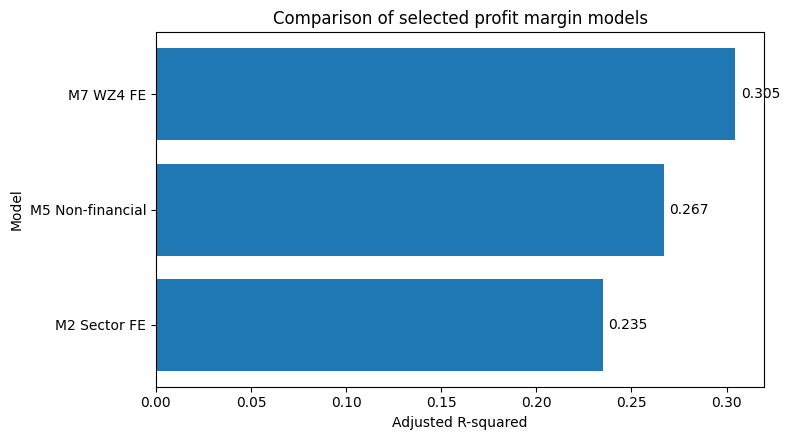

Saved:
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05D_econometric_results_writeup/05D_fig_01_selected_model_comparison.png
/content/drive/MyDrive/IBS_7_Thesis/Python Files/analysis_outputs/05_econometric_models/05D_econometric_results_writeup/05D_fig_01_selected_model_comparison.pdf


In [52]:
# ============================================================
# Cell 49 — Final model comparison plot
# ============================================================

import matplotlib.pyplot as plt

model_compare_final = pd.DataFrame([
    {"model": "M2 Sector FE", "adj_r_squared": 0.2348},
    {"model": "M7 WZ4 FE", "adj_r_squared": 0.3046},
    {"model": "M5 Non-financial", "adj_r_squared": 0.2670}
])

model_compare_final = model_compare_final.sort_values("adj_r_squared")

plt.figure(figsize=(8, 4.5))
plt.barh(model_compare_final["model"], model_compare_final["adj_r_squared"])
plt.xlabel("Adjusted R-squared")
plt.ylabel("Model")
plt.title("Comparison of selected profit margin models")

for i, value in enumerate(model_compare_final["adj_r_squared"]):
    plt.text(value + 0.003, i, f"{value:.3f}", va="center")

plt.tight_layout()

fig_path_png = os.path.join(WRITEUP_DIR, "05D_fig_01_selected_model_comparison.png")
fig_path_pdf = os.path.join(WRITEUP_DIR, "05D_fig_01_selected_model_comparison.pdf")

plt.savefig(fig_path_png, dpi=300, bbox_inches="tight")
plt.savefig(fig_path_pdf, bbox_inches="tight")
plt.show()

print("Saved:")
print(fig_path_png)
print(fig_path_pdf)

In [53]:
# ============================================================
# Cell 50 — Thesis-ready text: model setup
# ============================================================

model_setup_text = """
The econometric analysis examines the relationship between financial structure and profitability
using firm-level observations from the cleaned German company dataset. Profit margin is used as the
main profitability outcome because the model comparison showed stronger explanatory power for
profit margin than for ROA. The baseline model includes debt ratio, cash-to-assets, receivables-to-assets,
asset turnover, and firm size measured by log assets. In addition, WZ industry fixed effects and
financial year fixed effects are included to account for systematic differences across industries and
years.

The main baseline specification uses broad WZ section fixed effects. An extended model replaces
the broad sector controls with grouped WZ 4-digit fixed effects to capture more detailed industry
heterogeneity. A further robustness model excludes financial-sector firms, because financial firms
have structurally different balance sheets and may influence the estimated relationships.
All models are estimated using OLS with HC3 robust standard errors.
"""

model_setup_path = os.path.join(WRITEUP_DIR, "05D_03_thesis_text_model_setup.txt")

with open(model_setup_path, "w") as f:
    f.write(model_setup_text)

print(model_setup_text)
print("Saved:", model_setup_path)


The econometric analysis examines the relationship between financial structure and profitability
using firm-level observations from the cleaned German company dataset. Profit margin is used as the
main profitability outcome because the model comparison showed stronger explanatory power for
profit margin than for ROA. The baseline model includes debt ratio, cash-to-assets, receivables-to-assets,
asset turnover, and firm size measured by log assets. In addition, WZ industry fixed effects and
financial year fixed effects are included to account for systematic differences across industries and
years.

The main baseline specification uses broad WZ section fixed effects. An extended model replaces
the broad sector controls with grouped WZ 4-digit fixed effects to capture more detailed industry
heterogeneity. A further robustness model excludes financial-sector firms, because financial firms
have structurally different balance sheets and may influence the estimated relationships.
All models 

In [54]:
# ============================================================
# Cell 52 — Thesis-ready text: robustness and stability
# ============================================================

robustness_text = """
Several checks were conducted to evaluate the stability of the econometric findings.
First, models were compared on a common sample to ensure that differences in adjusted R-squared
were not caused by changes in sample size. The grouped WZ4 model continued to outperform the
broad sector model on the same set of observations.

Second, cluster-robust standard errors were estimated for the grouped WZ4 model. The main results
for debt ratio, cash-to-assets, and asset turnover remained statistically significant after clustering by
industry group. This suggests that these findings are not only due to heteroskedasticity or within-industry
correlation.

Third, the model was re-estimated after excluding individual financial years. The main coefficient
directions remained stable, indicating that the results are not driven by a single year. This is important
because the dataset contains a large share of observations from 2023.

Finally, the exclusion of financial-sector firms produced similar conclusions for debt ratio, cash-to-assets,
and asset turnover. This supports the robustness of the main profitability results outside the structurally
different financial sector.
"""

robustness_path = os.path.join(WRITEUP_DIR, "05D_05_thesis_text_robustness.txt")

with open(robustness_path, "w") as f:
    f.write(robustness_text)

print(robustness_text)
print("Saved:", robustness_path)


Several checks were conducted to evaluate the stability of the econometric findings.
First, models were compared on a common sample to ensure that differences in adjusted R-squared
were not caused by changes in sample size. The grouped WZ4 model continued to outperform the
broad sector model on the same set of observations.

Second, cluster-robust standard errors were estimated for the grouped WZ4 model. The main results
for debt ratio, cash-to-assets, and asset turnover remained statistically significant after clustering by
industry group. This suggests that these findings are not only due to heteroskedasticity or within-industry
correlation.

Third, the model was re-estimated after excluding individual financial years. The main coefficient
directions remained stable, indicating that the results are not driven by a single year. This is important
because the dataset contains a large share of observations from 2023.

Finally, the exclusion of financial-sector firms produced similar con